In [1]:
# Setup Python path to import sgg_benchmark
import sys
import os

# Get the absolute path to the sgg root directory
current_file = os.path.abspath(os.getcwd())
sgg_root = os.path.dirname(current_file)  # Go up from demo to sgg

# Add sgg root to Python path
if sgg_root not in sys.path:
    sys.path.insert(0, sgg_root)

# Change working directory to sgg root for relative imports
os.chdir(sgg_root)

print(f"Added to Python path: {sgg_root}")
print(f"Changed working directory to: {os.getcwd()}")
print(f"sgg_benchmark exists: {os.path.exists(os.path.join(sgg_root, 'sgg_benchmark'))}")

Added to Python path: /mnt/f/gdrive/Takeout/Drive/School/4 Fourth year/BCTN/code/sgg-feedback/sgg
Changed working directory to: /mnt/f/gdrive/Takeout/Drive/School/4 Fourth year/BCTN/code/sgg-feedback/sgg
sgg_benchmark exists: True


In [2]:
from demo.demo_model import SGG_Model
import cv2
import os

import matplotlib.pyplot as plt

config_path = "checkpoints/react_PSG/config.yml"
# weights_path = "checkpoints/react_PSG/best_model_epoch_11.pth"
weights_path = "checkpoints/react_PSG/my_best.pth"

# source = "demo/example.jpg"
source = "my_script/yolo_augmentation/images/000000581930.jpg"
model = SGG_Model(config_path, weights_path, rel_conf=0.1, box_conf=0.01, show_fps=False)

2025-12-10 15:45:23.684 | INFO     | sgg_benchmark.data.build:get_dataset_statistics:32 - ----------------------------------------------------------------------------------------------------
2025-12-10 15:45:23.685 | INFO     | sgg_benchmark.data.build:get_dataset_statistics:33 - get dataset statistics...
2025-12-10 15:45:23.695 | INFO     | sgg_benchmark.data.build:get_dataset_statistics:74 - Loading data statistics from: checkpoints/react_PSG/PSG_train_statistics.cache
2025-12-10 15:45:23.685 | INFO     | sgg_benchmark.data.build:get_dataset_statistics:33 - get dataset statistics...
2025-12-10 15:45:23.695 | INFO     | sgg_benchmark.data.build:get_dataset_statistics:74 - Loading data statistics from: checkpoints/react_PSG/PSG_train_statistics.cache
2025-12-10 15:45:23.696 | INFO     | sgg_benchmark.data.build:get_dataset_statistics:75 - ----------------------------------------------------------------------------------------------------
2025-12-10 15:45:23.696 | INFO     | sgg_benchma

2025-12-10 15:45:44.626 | INFO     | sgg_benchmark.utils.logger:setup_logger:31 - Using loguru logger with level: INFO
Overriding model.yaml nc=80 with nc=133

                   from  n    params  module                                       arguments                     
Overriding model.yaml nc=80 with nc=133

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
 

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/react_PSG/my_best.pth'

In [3]:
source = "my_script/yolo_augmentation/images/000000581933.jpg"

In [7]:
if '.jpg' in source:
    example_img = source

    img = cv2.imread(example_img)

    clean_img, graph = model.predict(img, visu_type='image')

elif os.path.isdir(source):
    os.makedirs(source + '/results', exist_ok=True)

    for file in os.listdir(source):
        example_img = source + '/' + file

        if '.jpg' not in example_img:
            continue

        img = cv2.imread(example_img)

        clean_img, graph = model.predict(img, visu_type='image')

        # to rgb
        clean_img = cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB)
        # save to dir
        cv2.imwrite(source + '/results/res_' + file, clean_img)

Objects detected:  0
Relationships detected:  0


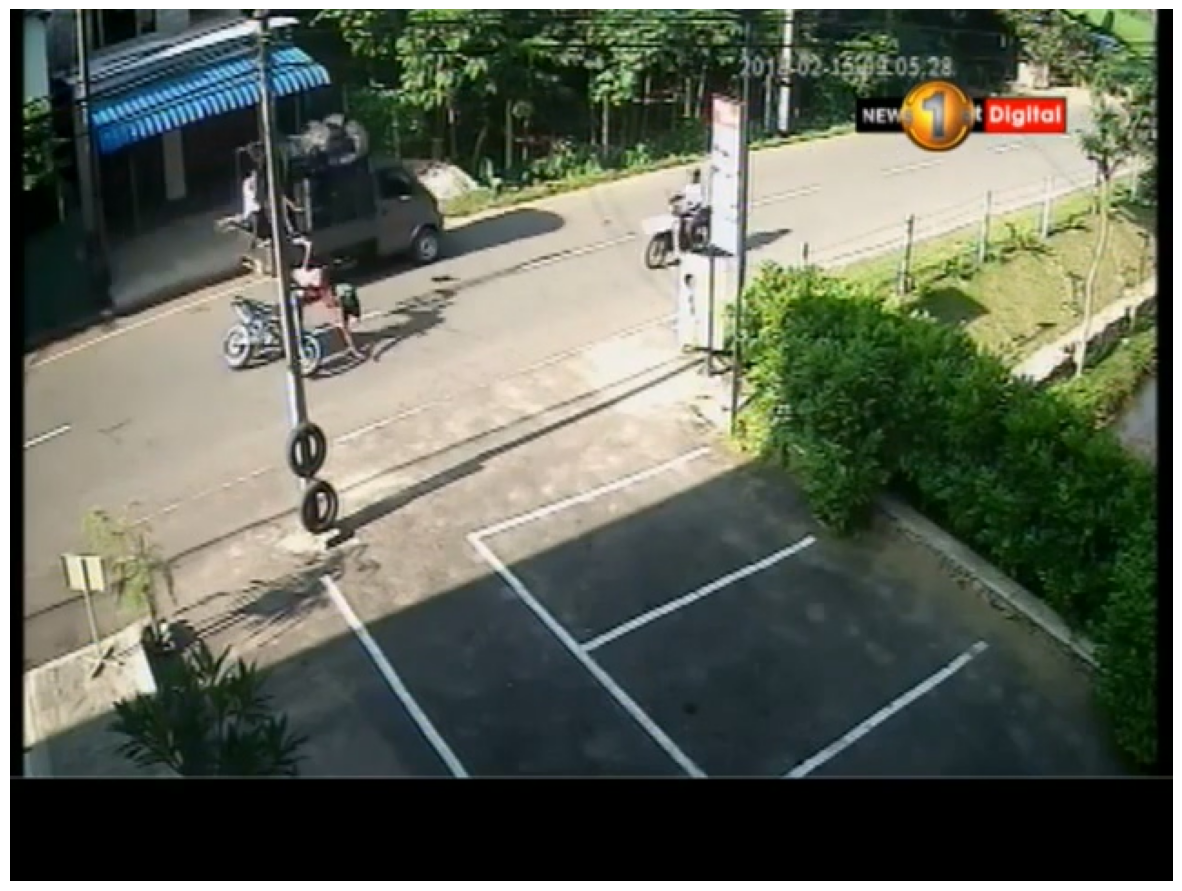

In [8]:
plt.figure(figsize=(15, 15))  # You can adjust the size as needed
plt.imshow(clean_img)
plt.axis('off')
plt.show()

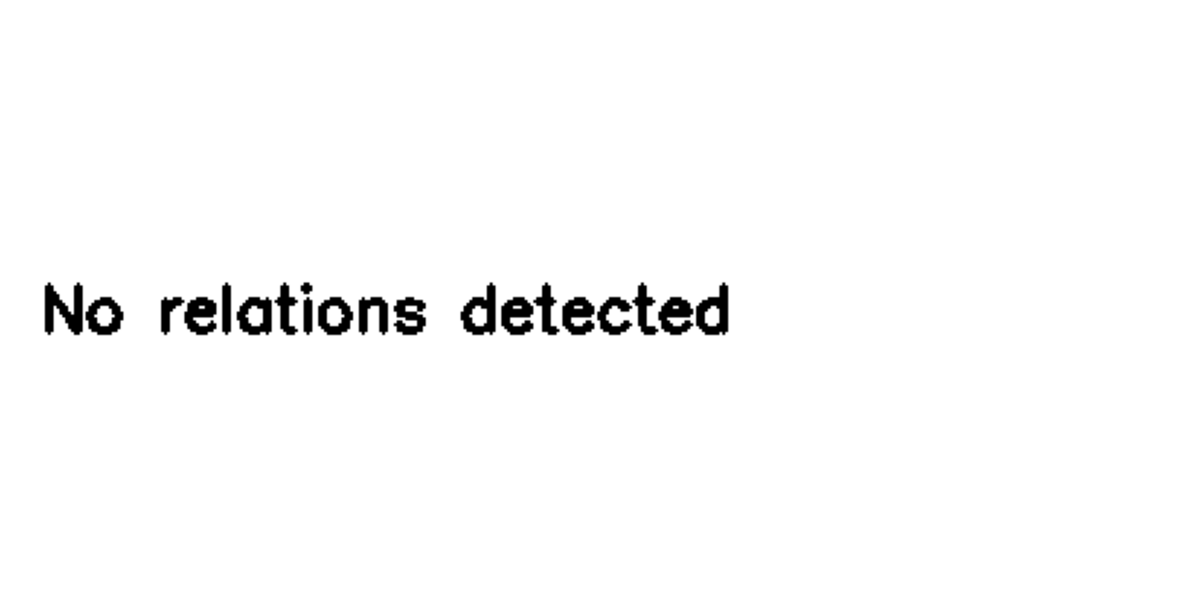

In [10]:
plt.figure(figsize=(15, 8))  # You can adjust the size as needed
plt.imshow(graph)
plt.axis('off')
plt.show()